# Lab 20: Bubble Plots - Data Visualization
## IBM Data Analytics Capstone Project
### Objective: Create bubble plots to visualize distributions, relationships, compositions and comparisons

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv")

# Map Age to numeric
age_mapping = {
    'Under 18 years old': 16, '18-24 years old': 21,
    '25-34 years old': 29, '35-44 years old': 39,
    '45-54 years old': 49, '55-64 years old': 59,
    '65 years or older': 70
}
df['Age_Numeric'] = df['Age'].map(age_mapping)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully!
Shape: (65437, 115)


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat,Age_Numeric
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.0
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,39.0
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN,49.0
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN,21.0
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN,21.0


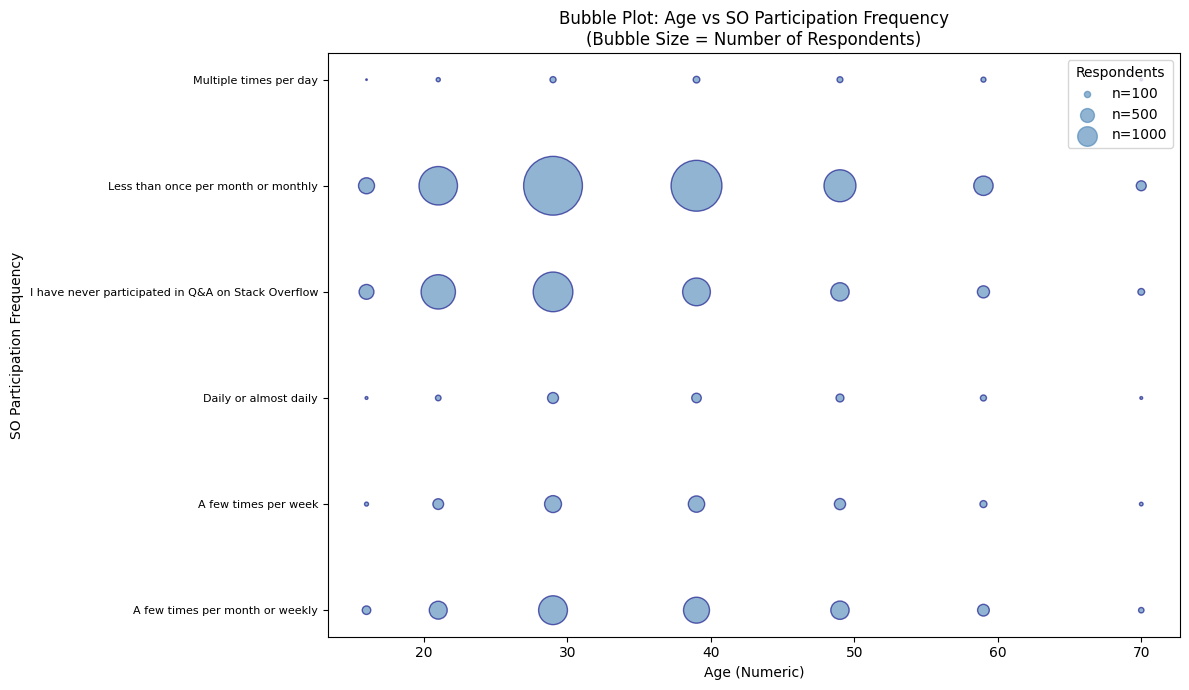

bubble plot saved!


In [4]:
# use count as bubble size for more visual variation
plt.figure(figsize=(12, 7))
scatter = plt.scatter(QUERY_DATA['Age_Numeric'], QUERY_DATA['SOPartFreq_Num'],
            s=QUERY_DATA['count'] / 5,
            alpha=0.6, color='steelblue', edgecolors='navy')
plt.title('Bubble Plot: Age vs SO Participation Frequency\n(Bubble Size = Number of Respondents)')
plt.xlabel('Age (Numeric)')
plt.ylabel('SO Participation Frequency')
plt.yticks(list(freq_mapping.values()), list(freq_mapping.keys()), fontsize=8)

# Add size legend
for size in [100, 500, 1000]:
    plt.scatter([], [], s=size/5, color='steelblue', alpha=0.6, label=f'n={size}')
plt.legend(title='Respondents', loc='upper right')
plt.tight_layout()
plt.savefig('bubble_age_sopartfreq.png', dpi=150, bbox_inches='tight')
plt.show()
print("bubble plot saved!")

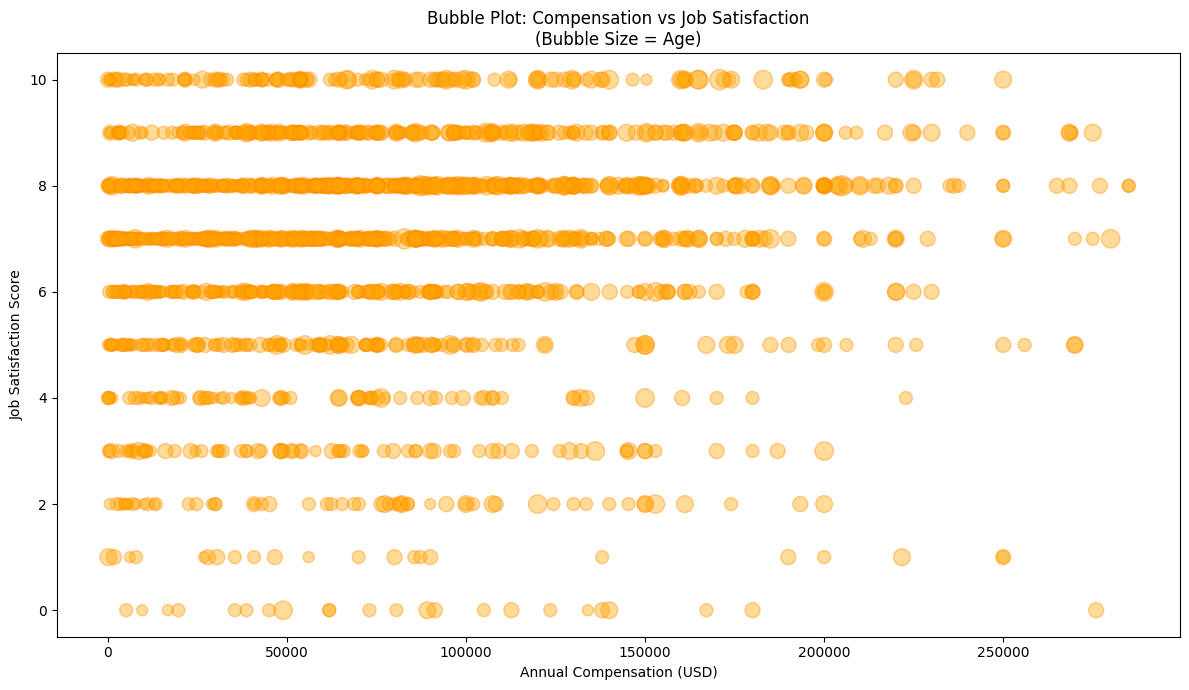

Compensation vs JobSat bubble plot saved!


In [3]:
sample = df[['ConvertedCompYearly', 'JobSat', 'Age_Numeric']].dropna()
sample = sample[sample['ConvertedCompYearly'] < 300000].sample(2000, random_state=42)

plt.figure(figsize=(12, 7))
plt.scatter(sample['ConvertedCompYearly'], sample['JobSat'],
            s=sample['Age_Numeric'] * 3,
            alpha=0.4, color='orange', edgecolors='darkorange')
plt.title('Bubble Plot: Compensation vs Job Satisfaction\n(Bubble Size = Age)')
plt.xlabel('Annual Compensation (USD)')
plt.ylabel('Job Satisfaction Score')
plt.tight_layout()
plt.savefig('bubble_comp_jobsat.png', dpi=150, bbox_inches='tight')
plt.show()
print("Compensation vs JobSat bubble plot saved!")

/var/folders/l6/_t_zyy_55010xg3998z5sfyc0000gn/T/ipykernel_89806/681907450.py:7: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask = (df['LanguageHaveWorkedWith'].str.contains(lang, na=False)) & (df['Age'] == age)


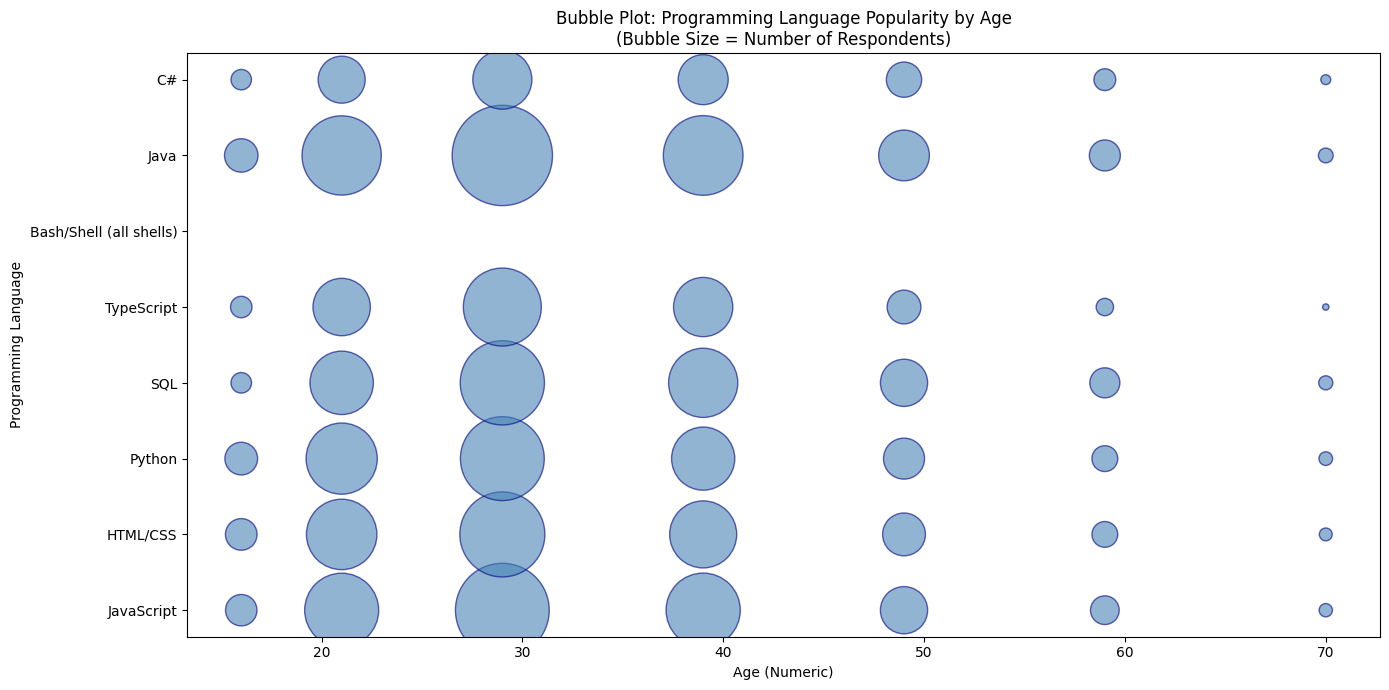

Technology preferences bubble plot saved!


In [5]:
# Top 8 languages by age group
top8_langs = df['LanguageHaveWorkedWith'].dropna().str.split(';').explode().value_counts().head(8).index.tolist()

lang_age_data = []
for lang in top8_langs:
    for age, age_num in age_mapping.items():
        mask = (df['LanguageHaveWorkedWith'].str.contains(lang, na=False)) & (df['Age'] == age)
        count = mask.sum()
        lang_age_data.append({'Language': lang, 'Age_Numeric': age_num, 'Count': count})

df_lang_age = pd.DataFrame(lang_age_data)

plt.figure(figsize=(14, 7))
plt.scatter(df_lang_age['Age_Numeric'], df_lang_age['Language'],
            s=df_lang_age['Count'] / 3,
            alpha=0.6, color='steelblue', edgecolors='navy')
plt.title('Bubble Plot: Programming Language Popularity by Age\n(Bubble Size = Number of Respondents)')
plt.xlabel('Age (Numeric)')
plt.ylabel('Programming Language')
plt.tight_layout()
plt.savefig('bubble_lang_age.png', dpi=150, bbox_inches='tight')
plt.show()
print("Technology preferences bubble plot saved!")

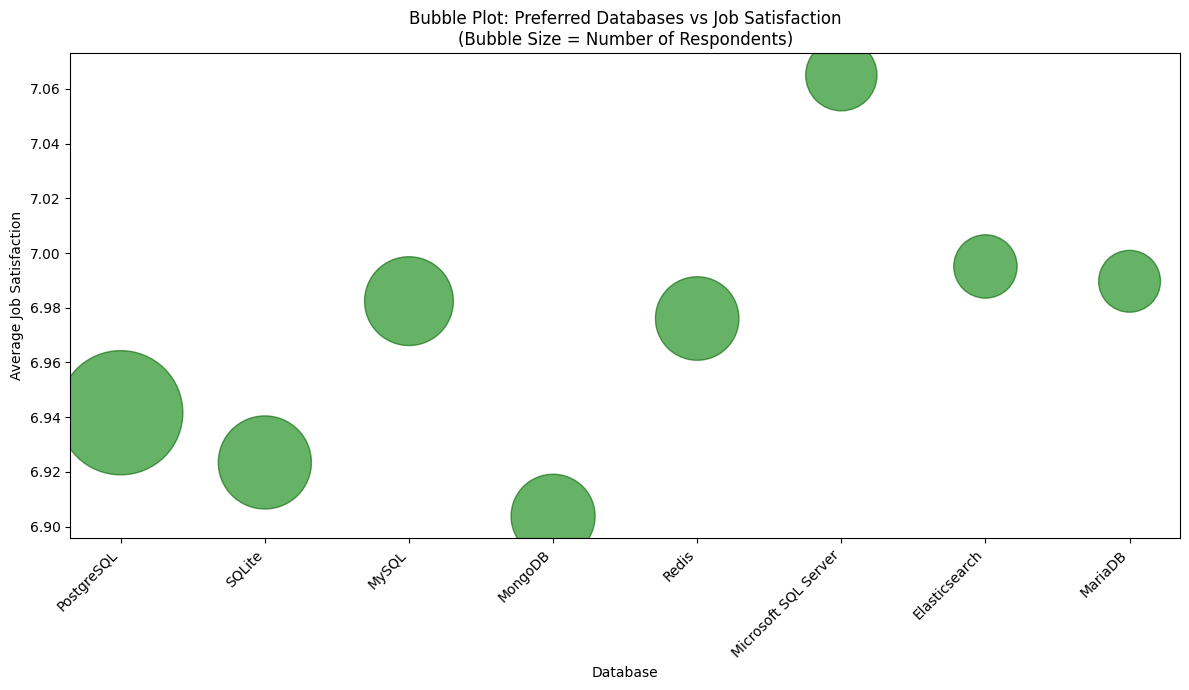

Databases vs JobSat bubble plot saved!
               Database  AvgJobSat  Count
0            PostgreSQL   6.941633  24005
1                SQLite   6.923458  13489
2                 MySQL   6.982421  12269
3               MongoDB   6.903802  10982
4                 Redis   6.976072  10847
5  Microsoft SQL Server   7.065005   7905
6         Elasticsearch   6.995094   6246
7               MariaDB   6.989681   5947


In [6]:
# Top 8 databases vs avg job satisfaction
top8_db = df['DatabaseWantToWorkWith'].dropna().str.split(';').explode().value_counts().head(8).index.tolist()

db_data = []
for db in top8_db:
    mask = df['DatabaseWantToWorkWith'].str.contains(db, na=False)
    avg_sat = df[mask]['JobSat'].mean()
    count = mask.sum()
    db_data.append({'Database': db, 'AvgJobSat': avg_sat, 'Count': count})

df_db = pd.DataFrame(db_data)

plt.figure(figsize=(12, 7))
plt.scatter(range(len(df_db)), df_db['AvgJobSat'],
            s=df_db['Count'] / 3,
            alpha=0.6, color='green', edgecolors='darkgreen')
plt.title('Bubble Plot: Preferred Databases vs Job Satisfaction\n(Bubble Size = Number of Respondents)')
plt.xlabel('Database')
plt.ylabel('Average Job Satisfaction')
plt.xticks(range(len(df_db)), df_db['Database'], rotation=45, ha='right')
plt.tight_layout()
plt.savefig('bubble_db_jobsat.png', dpi=150, bbox_inches='tight')
plt.show()
print("Databases vs JobSat bubble plot saved!")
print(df_db[['Database', 'AvgJobSat', 'Count']])

/var/folders/l6/_t_zyy_55010xg3998z5sfyc0000gn/T/ipykernel_89806/438035925.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask = df['DevType'].str.contains(dev, na=False)


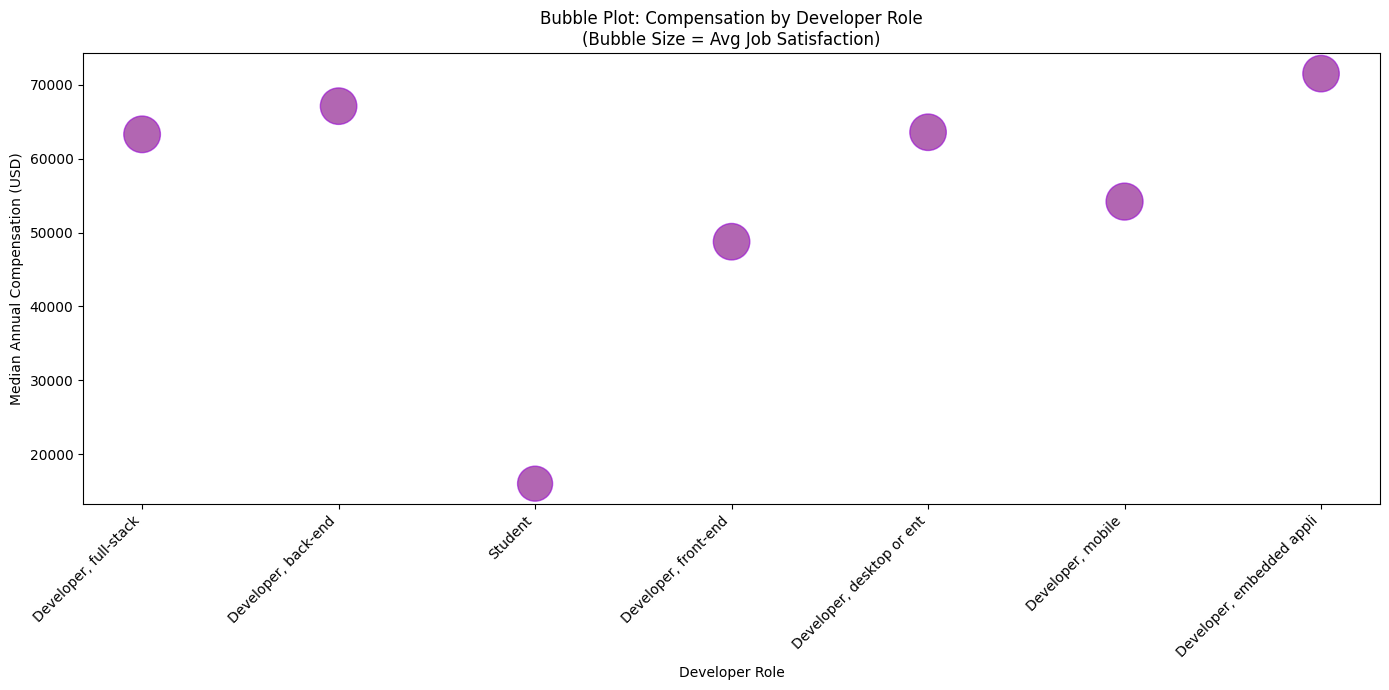

Compensation by developer role saved!
                                         DevType  AvgComp  AvgJobSat
0                          Developer, full-stack  63316.0   6.952484
1                            Developer, back-end  67132.0   6.901411
2                                        Student  16000.0   6.355422
3                           Developer, front-end  48774.5   6.902295
4  Developer, desktop or enterprise applications  63600.0   6.895167
6                              Developer, mobile  54207.0   7.085478
7    Developer, embedded applications or devices  71538.0   6.881593


In [7]:
# Top 8 developer roles
top8_dev = df['DevType'].dropna().str.split(';').explode().value_counts().head(8).index.tolist()

dev_data = []
for dev in top8_dev:
    mask = df['DevType'].str.contains(dev, na=False)
    avg_comp = df[mask]['ConvertedCompYearly'].median()
    avg_sat = df[mask]['JobSat'].mean()
    count = mask.sum()
    dev_data.append({'DevType': dev, 'AvgComp': avg_comp, 'AvgJobSat': avg_sat, 'Count': count})

df_dev = pd.DataFrame(dev_data).dropna()

plt.figure(figsize=(14, 7))
plt.scatter(range(len(df_dev)), df_dev['AvgComp'],
            s=df_dev['AvgJobSat'] * 100,
            alpha=0.6, color='purple', edgecolors='darkviolet')
plt.title('Bubble Plot: Compensation by Developer Role\n(Bubble Size = Avg Job Satisfaction)')
plt.xlabel('Developer Role')
plt.ylabel('Median Annual Compensation (USD)')
plt.xticks(range(len(df_dev)), [d[:25] for d in df_dev['DevType']], 
           rotation=45, ha='right')
plt.tight_layout()
plt.savefig('bubble_comp_devtype.png', dpi=150, bbox_inches='tight')
plt.show()
print("Compensation by developer role saved!")
print(df_dev[['DevType', 'AvgComp', 'AvgJobSat']])

Collab tools column: True


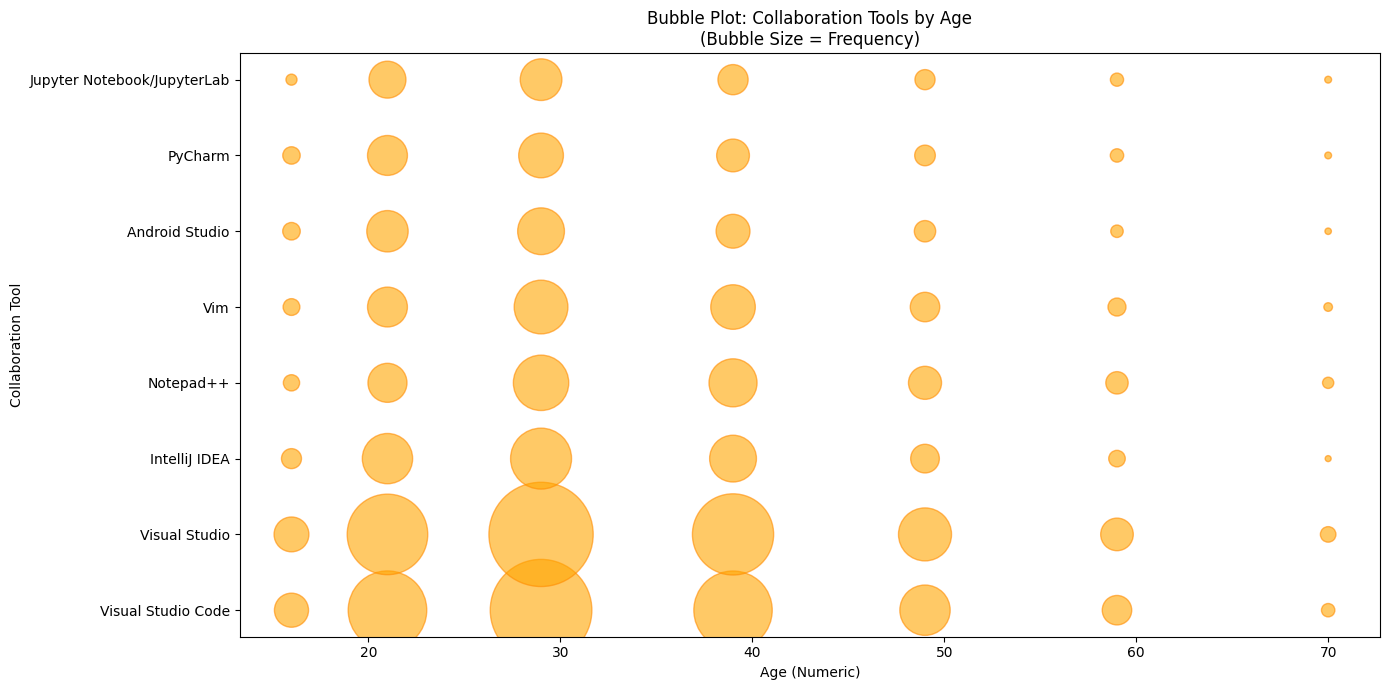

Collaboration tools bubble plot saved!


In [9]:
# Check column name first
print("Collab tools column:", 'NEWCollabToolsHaveWorkedWith' in df.columns)
collab_col = 'NEWCollabToolsHaveWorkedWith' if 'NEWCollabToolsHaveWorkedWith' in df.columns else None

if collab_col:
    top8_tools = df[collab_col].dropna().str.split(';').explode().value_counts().head(8).index.tolist()
    tool_data = []
    for tool in top8_tools:
        for age, age_num in age_mapping.items():
            mask = (df[collab_col].str.contains(tool, na=False)) & (df['Age'] == age)
            count = mask.sum()
            tool_data.append({'Tool': tool, 'Age_Numeric': age_num, 'Count': count})

    df_tools = pd.DataFrame(tool_data)
    plt.figure(figsize=(14, 7))
    plt.scatter(df_tools['Age_Numeric'], df_tools['Tool'],
                s=df_tools['Count'] / 3,
                alpha=0.6, color='orange', edgecolors='darkorange')
    plt.title('Bubble Plot: Collaboration Tools by Age\n(Bubble Size = Frequency)')
    plt.xlabel('Age (Numeric)')
    plt.ylabel('Collaboration Tool')
    plt.tight_layout()
    plt.savefig('bubble_tools_age.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Collaboration tools bubble plot saved!")
else:
    print("Column not found - checking available columns:")
    print([c for c in df.columns if 'collab' in c.lower()])

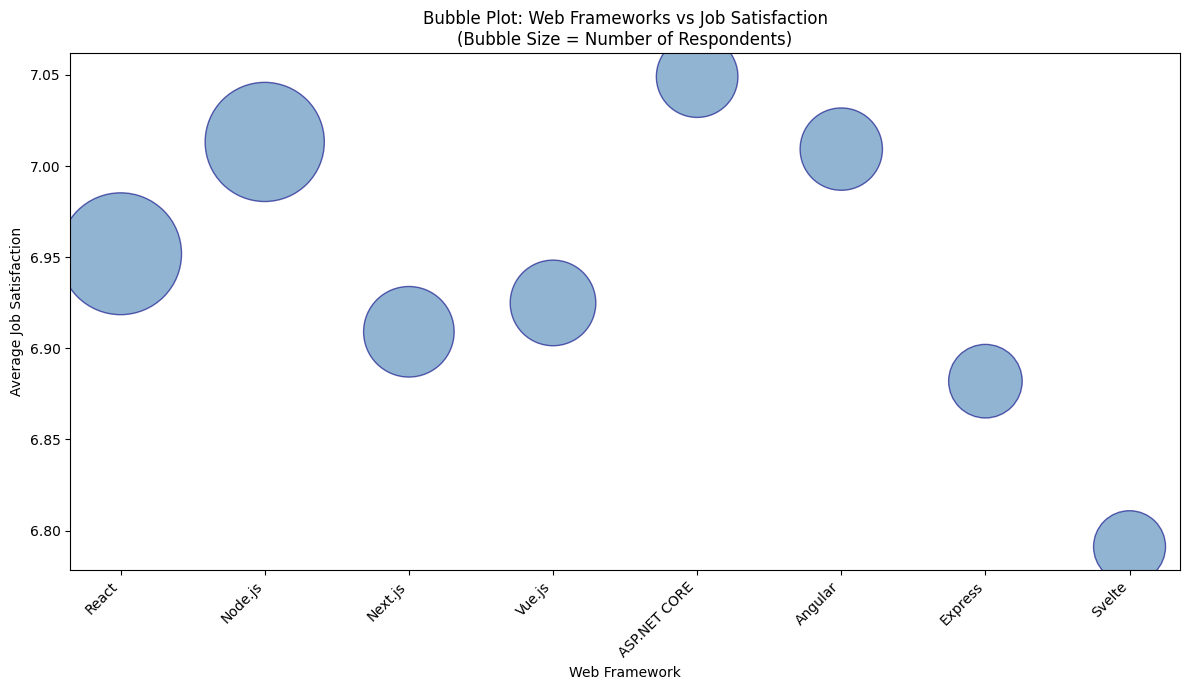

Web frameworks bubble plot saved!
      Framework  AvgJobSat  Count
0         React   6.951880  15404
1       Node.js   7.013227  14735
2       Next.js   6.909070   8507
3        Vue.js   6.924895   7604
4  ASP.NET CORE   7.049059   6905
5       Angular   7.009290   7034
6       Express   6.881961   5616
7        Svelte   6.791144   5374


In [10]:
# Top 8 web frameworks vs job satisfaction
top8_web = df['WebframeWantToWorkWith'].dropna().str.split(';').explode().value_counts().head(8).index.tolist()

web_data = []
for web in top8_web:
    mask = df['WebframeWantToWorkWith'].str.contains(web, na=False)
    avg_sat = df[mask]['JobSat'].mean()
    count = mask.sum()
    web_data.append({'Framework': web, 'AvgJobSat': avg_sat, 'Count': count})

df_web = pd.DataFrame(web_data).dropna()

plt.figure(figsize=(12, 7))
plt.scatter(range(len(df_web)), df_web['AvgJobSat'],
            s=df_web['Count'] / 2,
            alpha=0.6, color='steelblue', edgecolors='navy')
plt.title('Bubble Plot: Web Frameworks vs Job Satisfaction\n(Bubble Size = Number of Respondents)')
plt.xlabel('Web Framework')
plt.ylabel('Average Job Satisfaction')
plt.xticks(range(len(df_web)), df_web['Framework'], rotation=45, ha='right')
plt.tight_layout()
plt.savefig('bubble_webframe_jobsat.png', dpi=150, bbox_inches='tight')
plt.show()
print("Web frameworks bubble plot saved!")
print(df_web[['Framework', 'AvgJobSat', 'Count']])

/var/folders/l6/_t_zyy_55010xg3998z5sfyc0000gn/T/ipykernel_89806/445418369.py:8: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask = (df['LanguageAdmired'].str.contains(lang, na=False)) & (df['Country'] == country)


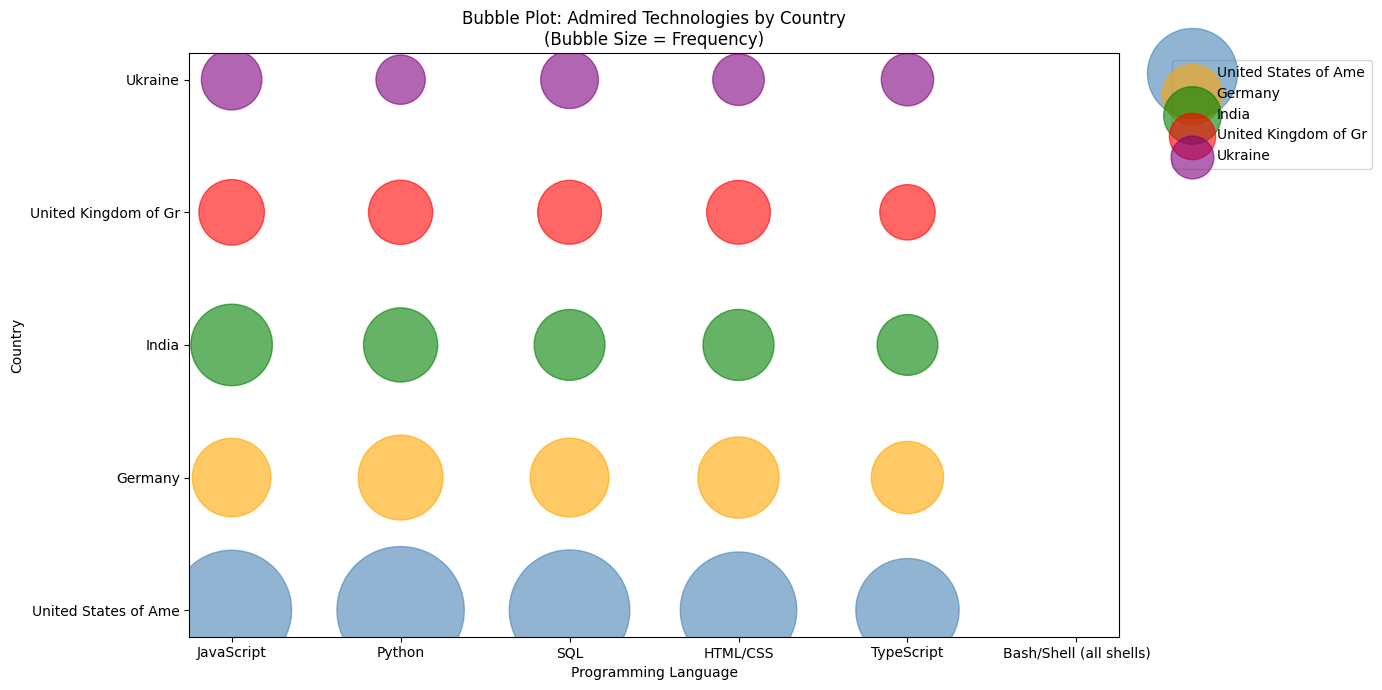

Admired technologies by country saved!


In [11]:
# Top 6 languages admired vs top 5 countries
top6_langs = df['LanguageAdmired'].dropna().str.split(';').explode().value_counts().head(6).index.tolist()
top5_countries = df['Country'].value_counts().head(5).index.tolist()

admire_data = []
for lang in top6_langs:
    for country in top5_countries:
        mask = (df['LanguageAdmired'].str.contains(lang, na=False)) & (df['Country'] == country)
        count = mask.sum()
        admire_data.append({'Language': lang, 'Country': country, 'Count': count})

df_admire = pd.DataFrame(admire_data)

plt.figure(figsize=(14, 7))
colors = ['steelblue','orange','green','red','purple']
for i, country in enumerate(top5_countries):
    data = df_admire[df_admire['Country'] == country]
    plt.scatter(data['Language'], [i]*len(data),
                s=data['Count'] * 2,
                alpha=0.6, color=colors[i], label=country[:20])

plt.title('Bubble Plot: Admired Technologies by Country\n(Bubble Size = Frequency)')
plt.xlabel('Programming Language')
plt.ylabel('Country')
plt.yticks(range(len(top5_countries)), [c[:20] for c in top5_countries])
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('bubble_admired_country.png', dpi=150, bbox_inches='tight')
plt.show()
print("Admired technologies by country saved!")